<a href="https://colab.research.google.com/github/dangbenzy/Projects/blob/main/Finetuning_Mobilenetv3_with_MNIST_data_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [120]:
!pip install -q torchinfo

In [121]:
import torch  # PyTorch core library for deep learning
import torch.nn as nn  # Neural network module in PyTorch
from torch.optim import Adam  # Adam optimizer for training models
import torch.nn.functional as F  # Functional interface for PyTorch layers
from torch.utils.data import DataLoader, Dataset  # Utilities for handling datasets and data loading
from torchinfo import summary  # Prints model architecture summary
from torch.utils.tensorboard import SummaryWriter  # Logging utility for TensorBoard

import torchvision  # PyTorch's library for image processing
from torchvision import datasets  # Datasets module for common image datasets
from torchvision.transforms import v2 as transforms  # Image transformation utilities
from torchvision.ops import Conv2dNormActivation  # Convolution layers with normalization and activation
from torchvision.models import mobilenet_v3_small

from dataclasses import dataclass  # Data structure utility for structured storage
from sklearn.metrics import confusion_matrix  # Computes confusion matrix for classification
from sklearn.model_selection import train_test_split  # Splits dataset into training and testing sets
import seaborn as sn  # Data visualization library, often used for heatmaps

import matplotlib.pyplot as plt  # Visualization library for creating plots
import time  # Provides time-related functions
import numpy as np  # Library for numerical computing and array operations
import random  # Standard library module for generating random numbers
import warnings  # Handles warning messages
import os  # Provides functionalities for interacting with the operating system
from tqdm import tqdm  # Displays progress bars for loops

import pandas as pd  # Library for data manipulation and analysis
import random  # Included twice, can be removed if unnecessary
# Ensures inline plotting in Jupyter notebooks
%matplotlib inline
warnings.filterwarnings("ignore")  # Suppresses warning messages

In [122]:
#Set seed for reproducibilty
def set_seed(seed):
    random.seed(seed)  # Set the seed for Python's built-in random module
    np.random.seed(seed)  # Set the seed for NumPy's random number generator
    torch.manual_seed(seed)  # Set the seed for PyTorch's random number generator

    if torch.cuda.is_available():  # Check if a CUDA-enabled GPU is available
       torch.cuda.manual_seed(seed)  # Set the seed for CUDA (single GPU)
       torch.cuda.manual_seed_all(seed)  # Set the seed for CUDA (multiple GPUs)
       torch.backends.cudnn.deterministic = True  # Ensure deterministic behavior for CuDNN
       torch.backends.cudnn.benchmark = True  # Enable benchmark mode for CuDNN (can improve performance)

set_seed(42)  # Set the random seed to 42 for reproducibility

Dataset and Training Parameters

In [123]:
batch_size = 32  # Number of samples per training batch
num_epochs= 20  # Number of epochs (full passes through dataset)
learning_rate= 1e-4  # Learning rate for optimizer

log_interval= 1  # Interval at which to log training progress
test_interval= 1  # Interval at which to test model performance
num_workers = 5  # Number of worker processes for data loading
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
data_root= '/content/drive/MyDrive/data/MNIST Dataset JPG format'

print (device)

cpu


In [124]:
test_root= os.path.join(data_root, 'MNIST - JPG - testing')
train_root= os.path.join(data_root, 'MNIST - JPG - training')
val_root= os.path.join(data_root, 'MNIST - JPG - validation')

Data Processing

In [125]:
transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                       std=[0.229, 0.224, 0.225])
])


Loading the Data using Imgagefolder on torch

In [126]:
train_data= datasets.ImageFolder(root= train_root, transform= transforms)
test_data= datasets.ImageFolder(root= test_root, transform= transforms)
val_data= datasets.ImageFolder(root= val_root, transform= transforms)


class_mapping = {v: k for k, v in train_data.class_to_idx.items()}
print(class_mapping)

{0: '0', 1: '1', 2: '2', 3: '3', 4: '4', 5: '5', 6: '6', 7: '7', 8: '8', 9: '9'}


Data Loader for Training purposes

In [127]:
train_loader = DataLoader(
    train_data,  # Dataset to load
    shuffle=True,  # Shuffle data at every epoch to improve generalization
    batch_size= batch_size,  # Number of samples per batch
    num_workers= num_workers  # Number of subprocesses for data loading
)

# Creating a DataLoader for validation data
val_loader = DataLoader(
    val_data,  # Dataset to load
    shuffle=False,  # No shuffling needed for validation data
    batch_size= batch_size,  # Number of samples per batch
    num_workers= num_workers  # Number of subprocesses for data loading
)

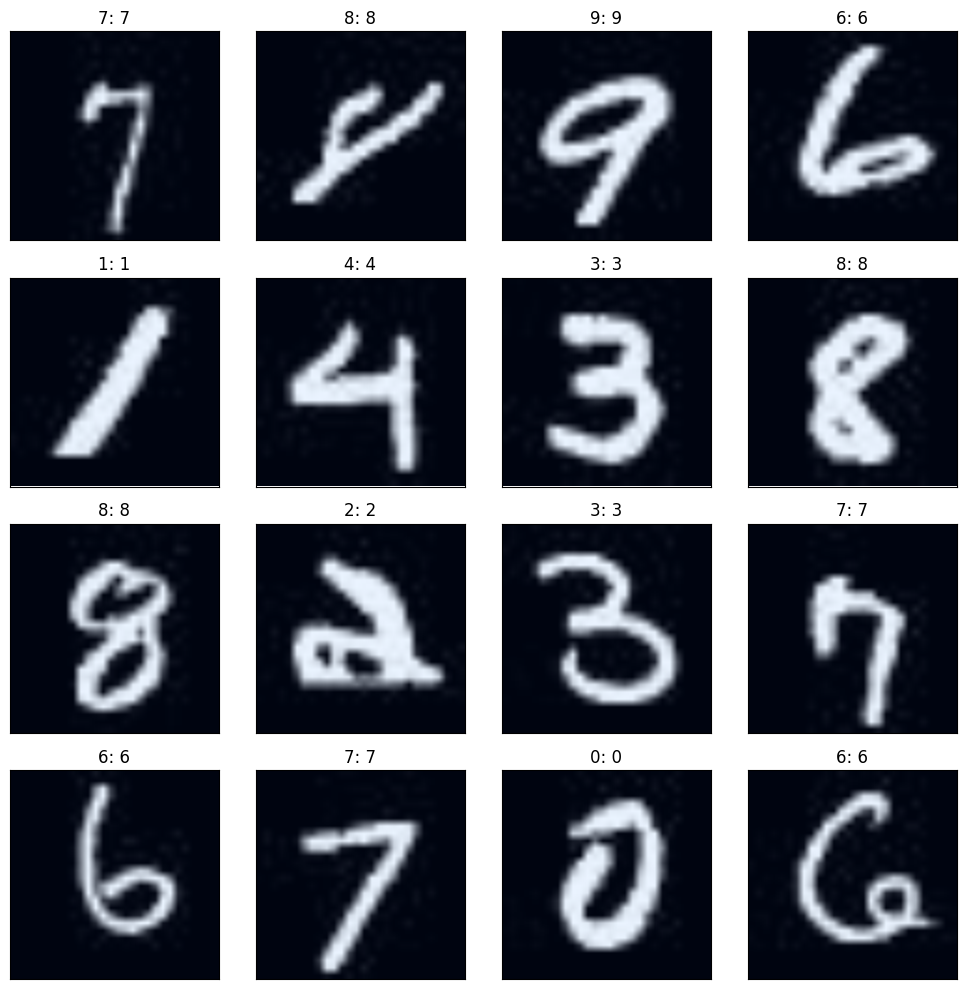

In [128]:
def visualize_images(dataloader, num_images=20):
    """
    Function to visualize a batch of images from the DataLoader.

    Parameters:
    dataloader (DataLoader): The PyTorch DataLoader containing image data.
    num_images (int): Number of images to visualize.
    """
    fig = plt.figure(figsize=(10, 10))  # Create a figure with a specified size

    # Retrieve the first batch from the DataLoader
    images, labels = next(iter(dataloader))

    num_rows = 4  # Define number of rows in the grid
    num_cols = int(np.ceil((num_images / num_rows)))  # Compute number of columns

    for idx in range(min(num_images, len(images))):  # Loop through the images up to num_images
        image, label = images[idx], labels[idx]  # Extract image and label

        ax = fig.add_subplot(num_rows, num_cols, idx + 1, xticks=[], yticks=[])  # Create subplot

        image = image.permute(1, 2, 0)  # Reorder dimensions for visualization (C, H, W) → (H, W, C)

        # Normalize the image to [0,1] for display
        image = (image - image.min()) / (image.max() - image.min())
        ax.imshow(image, cmap="gray")  # Display the image
        ax.set_title(f"{label.item()}: {class_mapping[label.item()]}")  # Set title with label info

    fig.tight_layout()  # Adjust layout for better spacing
    plt.show()  # Display the figure

# Call the function to visualize a sample of images from the training dataset
visualize_images(train_loader, num_images=16)

In [129]:
# Load the model
mobilenetv3_model = mobilenet_v3_small(weights="DEFAULT")

# Number of feature layers
num_feature_layers = len(mobilenetv3_model.features)
print(f"Number of feature layers: {num_feature_layers}")

# Number of classifier layers
num_classifier_layers = len(mobilenetv3_model.classifier)
print(f"Number of classifier layers: {num_classifier_layers}")

Number of feature layers: 13
Number of classifier layers: 4


In [130]:
for param in mobilenetv3_model.features[:8].parameters():  # Adjust as needed
    param.requires_grad = False

In [131]:
# Checking the number of classifiers for mobilenetv3
print(mobilenetv3_model.classifier[3])

Linear(in_features=1024, out_features=1000, bias=True)


In [132]:
# Replace the final linear layer of the classifier to match the number of classes in my dataset
mobilenetv3_model.classifier[3] = nn.Linear(in_features = 1024, out_features = len(class_mapping), bias = True)

# Check the final classifier after modifications
print(mobilenetv3_model.classifier[3])

model = mobilenetv3_model

Linear(in_features=1024, out_features=10, bias=True)


In [133]:
# Initializing the optimizer with model parameters and learning rate from the training configuration
optimizer = Adam(model.parameters(), lr=learning_rate)

# Print a summary of the MobileNetV3 model, specifying input shape and display settings
summary(model, input_size=(1, 3, 224, 224), row_settings=["var_names"], device="cpu")

Layer (type (var_name))                                      Output Shape              Param #
MobileNetV3 (MobileNetV3)                                    [1, 10]                   --
├─Sequential (features)                                      [1, 576, 7, 7]            --
│    └─Conv2dNormActivation (0)                              [1, 16, 112, 112]         --
│    │    └─Conv2d (0)                                       [1, 16, 112, 112]         (432)
│    │    └─BatchNorm2d (1)                                  [1, 16, 112, 112]         (32)
│    │    └─Hardswish (2)                                    [1, 16, 112, 112]         --
│    └─InvertedResidual (1)                                  [1, 16, 56, 56]           --
│    │    └─Sequential (block)                               [1, 16, 56, 56]           (744)
│    └─InvertedResidual (2)                                  [1, 24, 28, 28]           --
│    │    └─Sequential (block)                               [1, 24, 28, 28]           

In [134]:
def train(model, train_loader):
    """
    Trains the model for one epoch using the provided training data loader.

    Parameters:
    model (torch.nn.Module): The neural network model to be trained.
    train_loader (DataLoader): The DataLoader for training data.

    Returns:
    tuple: Average training loss and training accuracy.
    """
    model.train()  # Set the model to training mode
    model.to(device)  # Move the model to the appropriate device (GPU/CPU)

    running_loss = 0  # Variable to accumulate the total loss
    correct_predictions = 0  # Counter for correctly predicted samples
    total_train_samples = 0  # Counter for total training samples

    # Iterate through the training data
    for images, labels in tqdm(train_loader, desc="Training"):
        images, labels = images.to(device), labels.to(device)  # Move data to the selected device
        optimizer.zero_grad()  # Clear gradients from the previous step
        outputs = model(images)  # Forward pass to get predictions
        loss = F.cross_entropy(outputs, labels)  # Compute cross-entropy loss
        loss.backward()  # Backpropagation to compute gradients
        optimizer.step()  # Update model parameters

        running_loss += loss.item()  # Accumulate loss
        _, predicted = torch.max(outputs.data, dim=1)  # Get predicted class labels
        total_train_samples += labels.shape[0]  # Update total number of samples
        correct_predictions += (predicted == labels).sum().item()  # Count correct predictions

    train_avg_loss = running_loss / len(train_loader)  # Compute average loss
    train_accuracy = 100 * correct_predictions / total_train_samples  # Compute accuracy percentage
    return train_avg_loss, train_accuracy  # Return loss and accuracy

In [135]:
def validation(model, val_loader):
    """
    Evaluates the model performance using the provided validation data loader.

    Parameters:
    model (torch.nn.Module): The neural network model to be evaluated.
    val_loader (DataLoader): The DataLoader for validation data.

    Returns:
    tuple: Average validation loss and validation accuracy.
    """
    model.eval()  # Set the model to evaluation mode (disables dropout, batch norm updates)
    model.to(device)  # Move the model to the appropriate device (GPU/CPU)

    running_loss = 0  # Variable to accumulate the total loss
    correct_predictions = 0  # Counter for correctly predicted samples
    total_val_samples = 0  # Counter for total validation samples

    # Iterate through the validation data
    for images, labels in tqdm(val_loader, desc="Validation"):
        images, labels = images.to(device), labels.to(device)  # Move data to the selected device

        with torch.no_grad():  # Disable gradient computation for efficiency
            outputs = model(images)  # Forward pass to get predictions

        loss = F.cross_entropy(outputs, labels)  # Compute cross-entropy loss
        running_loss += loss.item()  # Accumulate loss
        _, predicted = torch.max(outputs.data, dim=1)  # Get predicted class labels
        total_val_samples += labels.shape[0]  # Update total number of samples
        correct_predictions += (predicted == labels).sum().item()  # Count correct predictions

    val_avg_loss = running_loss / len(val_loader)  # Compute average loss
    val_accuracy = 100 * correct_predictions / total_val_samples  # Compute accuracy percentage
    return val_avg_loss, val_accuracy  # Return loss and accuracy

In [136]:
def main(model, train_loader, val_loader):
    """
    Trains and validates the model over multiple epochs.

    Parameters:
    model (torch.nn.Module): The neural network model to be trained and validated.
    train_loader (DataLoader): The DataLoader for training data.
    val_loader (DataLoader): The DataLoader for validation data.

    Returns:
    tuple: Lists of training and validation losses and accuracies.
    """
    train_losses, val_losses = [], []  # Lists to store loss values for training and validation
    train_accuracies, val_accuracies = [], []  # Lists to store accuracy values for training and validation

    best_val_acc = 0.0  # Initialize the best validation accuracy
    best_weights = None  # Store the best model weights

    # Training loop for the number of epochs specified in train_config
    for epoch in range(num_epochs):
        train_loss, train_accuracy = train(model, train_loader)  # Perform training for one epoch
        val_loss, val_accuracy = validation(model, val_loader)  # Perform validation for one epoch

        # Append losses and accuracies to the respective lists
        train_losses.append(train_loss)
        train_accuracies.append(train_accuracy)
        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)

        # Print training progress
        print(f"Epoch {epoch+1:0>2}/{num_epochs} - Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.2f}% - Val Loss: {val_loss:.4f}, Val Accuracy: {val_accuracy:.2f}%")

        # Save the best model based on validation accuracy
        if val_accuracy > best_val_acc:
            best_val_acc = val_accuracy
            best_weights = model.state_dict()
            print(f"Saving best model...💾")
            torch.save(best_weights, "best.pt")  # Save model weights to a file

    return train_losses, train_accuracies, val_losses, val_accuracies  # Return training and validation metrics

In [137]:
train_losses, train_accuracies, val_losses, val_accuracies = main(model, train_loader, val_loader)

Validation: 100%|██████████| 7/7 [00:03<00:00,  2.20it/s]


Epoch 01/20 - Train Loss: 1.9704, Train Accuracy: 44.11% - Val Loss: 2.0159, Val Accuracy: 35.00%
Saving best model...💾


Validation: 100%|██████████| 7/7 [00:03<00:00,  2.15it/s]


Epoch 02/20 - Train Loss: 1.1458, Train Accuracy: 78.99% - Val Loss: 1.5267, Val Accuracy: 63.50%
Saving best model...💾


Validation: 100%|██████████| 7/7 [00:03<00:00,  1.89it/s]


...

Epoch 18/20 - Train Loss: 0.0063, Train Accuracy: 100.00% - Val Loss: 0.2862, Val Accuracy: 91.00%
Saving best model...💾


Validation: 100%|██████████| 7/7 [00:03<00:00,  2.22it/s]


Epoch 19/20 - Train Loss: 0.0064, Train Accuracy: 99.90% - Val Loss: 0.2030, Val Accuracy: 94.50%
Saving best model...💾


Validation: 100%|██████████| 7/7 [00:03<00:00,  1.95it/s]

Epoch 20/20 - Train Loss: 0.0051, Train Accuracy: 100.00% - Val Loss: 0.1765, Val Accuracy: 95.50%
Saving best model...💾
